# Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
print("loading dataset")
fo = np.load("./processed.npz")
x_test = fo["arr_4"]
y_test = fo["arr_5"]
fo = np.load("./ML_result/Resnet18_seed324.npz")
y_pred = fo["arr_1"]

norm_fac = np.max(y_test,1)[:,None]
y_test = y_test/norm_fac
y_pred = y_pred/norm_fac
print(y_test.shape)
srt_i = np.argsort(np.argmax(y_test[:,:401],1))

loading dataset
(250, 1604)


# Visualization

[0.02268476 0.03649165 0.0099625  0.01962464]
[0.01259125 0.01785154 0.02095692 0.00719837]
[0.01607413 0.01678906 0.03317496 0.01008889]
[0.01849761 0.02313148 0.007274   0.01658135]
[0.01464871 0.01439771 0.01254267 0.01599604]
[0.0081823  0.00784438 0.00596516 0.01182765]
[0.01229839 0.00839293 0.00643467 0.02038617]
[0.01499674 0.01784268 0.0137587  0.01452902]


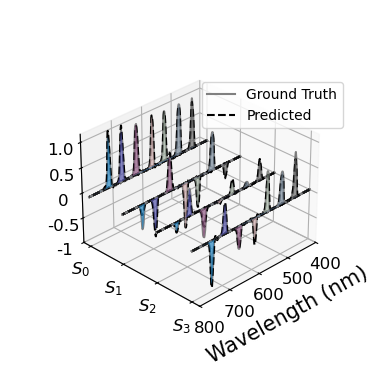

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def calc_error(y0,yr):
    result = np.zeros(4)
    result[0] = np.mean(np.square(y0[:401]-yr[:401]))
    max_i = np.argmax(y0[:401])
    for i in range(1,4):
        #result[i] = np.abs(y0[max_i+i*401]-yr[max_i+i*401])
        result[i] = np.mean(np.square((y0[i*401:(i+1)*401]-yr[i*401:(i+1)*401])/y0[max_i]))
    return np.sqrt(result)

def calc_L1(y0,yr):
    result = np.zeros(4)
    for i in range(4):
        result[i] = np.sum(np.abs(y0[i*401:(i+1)*401] - yr[i*401:(i+1)*401]))/np.sum(np.abs(y0[:401]))
    return result

idx = [237,200,159,119,81,40,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
ax = plt.figure().add_subplot(projection='3d')
wl_x = np.linspace(400,800,401)
L1_error = np.zeros(4)
for i in range(4):
    ys = np.ones_like(wl_x)*i
    for j in range(len(idx)):
        if i == 0:
            cur_error = calc_error(y_test[srt_i[idx[j]]],y_pred[srt_i[idx[j]]])
            L1_error += cur_error
            print(cur_error)
            
        ax.fill_between(wl_x, ys, y_test[srt_i[idx[j]],401*i:401*(i+1)],
                        wl_x, ys, np.zeros_like(wl_x),
                        facecolors=colors[j], alpha=.7)
        if i == 0 and j == 0:
            ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray",label="Ground Truth")
            ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black",label="Predicted")
        else:
            ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray")
            ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black")
L1_error = L1_error/len(idx)
print(L1_error)

ax.view_init(elev=30, azim=45, roll=0)
ax.set_xlim(400,800)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([0,1,2,3],[r"$S_0$",r"$S_1$",r"$S_2$",r"$S_3$"],fontsize=12)
ax.set_zticks([-1,-0.5,0,0.5,1.0],[str(i) for i in [-1,-0.5,0,0.5,1.0]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"",fontsize=15,labelpad=5,rotation=90)
ax.set_ylabel("",fontsize=15,labelpad=-10,rotation=-30)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=12)
ax.set_box_aspect(None, zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.66))

plt.savefig("S0.svg",transparent=True, bbox_inches='tight')

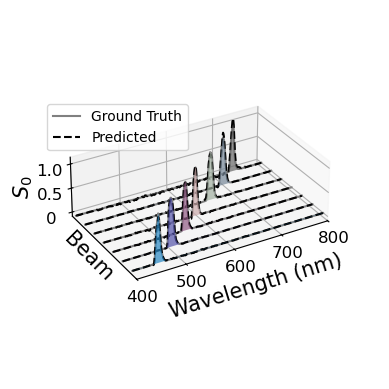

In [3]:
import matplotlib.pyplot as plt
import numpy as np

idx = [237,200,159,119,81,40,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
ax = plt.figure().add_subplot(projection='3d')
wl_x = np.linspace(400,800,401)

i=0
for j in range(len(idx)):
    ys = np.ones_like(wl_x)*j
    ax.fill_between(wl_x, ys, y_test[srt_i[idx[j]],401*i:401*(i+1)],
                    wl_x, ys, np.zeros_like(wl_x),
                    facecolors=colors[len(colors)-1-j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black")

ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([0,0.5,1.0],[str(i) for i in [0,0.5,1.0]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$S_0$",fontsize=15,labelpad=5,rotation=90)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-45)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_box_aspect([1.6,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.60))

plt.savefig("S0.svg",transparent=True, bbox_inches='tight')

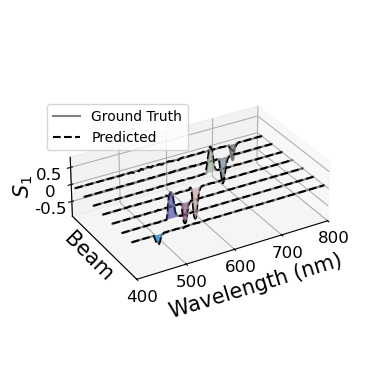

In [6]:
import matplotlib.pyplot as plt
import numpy as np

idx = [237,200,159,119,81,40,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
ax = plt.figure().add_subplot(projection='3d')
wl_x = np.linspace(400,800,401)

i=1
for j in range(len(idx)):
    ys = np.ones_like(wl_x)*j
    ax.fill_between(wl_x, ys, y_test[srt_i[idx[j]],401*i:401*(i+1)],
                    wl_x, ys, np.zeros_like(wl_x),
                    facecolors=colors[len(colors)-1-j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black")

ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([-0.5,0,0.5],[str(i) for i in [-0.5,0,0.5]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$S_1$",fontsize=15,labelpad=5,rotation=90)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-45)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_box_aspect([1.6,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.60))

plt.savefig("S1.svg",transparent=True, bbox_inches='tight')

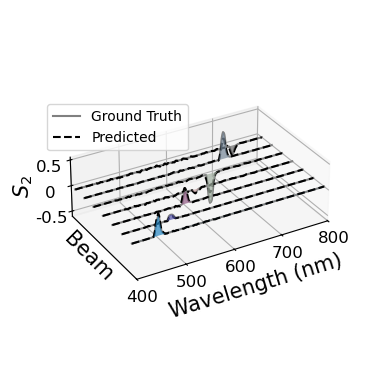

In [7]:
import matplotlib.pyplot as plt
import numpy as np

idx = [237,200,159,119,81,40,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
ax = plt.figure().add_subplot(projection='3d')
wl_x = np.linspace(400,800,401)

i=2
for j in range(len(idx)):
    ys = np.ones_like(wl_x)*j
    ax.fill_between(wl_x, ys, y_test[srt_i[idx[j]],401*i:401*(i+1)],
                    wl_x, ys, np.zeros_like(wl_x),
                    facecolors=colors[len(colors)-1-j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black")

ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([-0.5,0,0.5],[str(i) for i in [-0.5,0,0.5]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$S_2$",fontsize=15,labelpad=5,rotation=90)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-45)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_box_aspect([1.6,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.60))

plt.savefig("S2.svg",transparent=True, bbox_inches='tight')

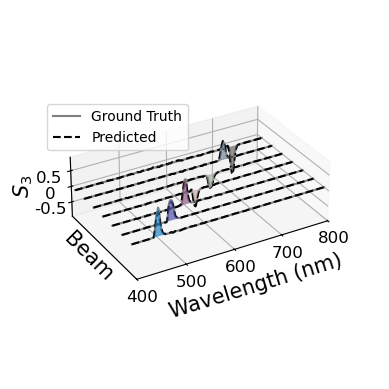

In [8]:
import matplotlib.pyplot as plt
import numpy as np

idx = [237,200,159,119,81,40,1]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']
ax = plt.figure().add_subplot(projection='3d')
wl_x = np.linspace(400,800,401)

i=3
for j in range(len(idx)):
    ys = np.ones_like(wl_x)*j
    ax.fill_between(wl_x, ys, y_test[srt_i[idx[j]],401*i:401*(i+1)],
                    wl_x, ys, np.zeros_like(wl_x),
                    facecolors=colors[len(colors)-1-j], alpha=.7)
    if j == 0:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray",label="Ground Truth")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black",label="Predicted")
    else:
        ax.plot(wl_x,ys,zs=y_test[srt_i[idx[j]],401*i:401*(i+1)],c="gray")
        ax.plot(wl_x,ys,zs=y_pred[srt_i[idx[j]],401*i:401*(i+1)],ls="--",color="black")

ax.view_init(elev=30, azim=60, roll=0)
ax.set_xlim(800,400)
ax.set_xticks([400,500,600,700,800],[str(i) for i in [400,500,600,700,800]],fontsize=12)
ax.set_yticks([])
ax.set_zticks([-0.5,0,0.5],[str(i) for i in [-0.5,0,0.5]],fontsize=12,)
#ax.tick_params(axis='both', which='major', pad=2)

ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$S_3$",fontsize=15,labelpad=5,rotation=90)
ax.set_ylabel("Beam",fontsize=15,labelpad=-10,rotation=-45)
ax.set_xlabel("Wavelength (nm)",fontsize=15,labelpad=20)
ax.set_box_aspect([1.6,1,0.5], zoom=0.7)
ax.legend(bbox_to_anchor=(0.5,0.60))

plt.savefig("S3.svg",transparent=True, bbox_inches='tight')

In [18]:
result = np.zeros(4)
for i in range(y_test.shape[0]):
    result += calc_error(y_test[i],y_pred[i])
result = result/y_test.shape[0]
result

array([0.01882788, 0.02000318, 0.01941531, 0.026535  ])

In [25]:
n_res = 401
MAE = np.zeros(4)
norm_fac = np.mean(np.max(y_test,1))
for i in range(y_test.shape[0]):
    idx = np.argmax(y_test[i,:n_res])
    for j in range(4):
        cur_test = y_test[i,j*n_res:(j+1)*n_res]
        cur_pred = y_pred[i,j*n_res:(j+1)*n_res]
        MAE[j] += np.abs(cur_test[idx] - cur_pred[idx])/norm_fac/y_test.shape[0]
MAE,norm_fac

(array([0.06676423, 0.10676866, 0.0956448 , 0.16600275]), 0.26415148)